# Phase 4 — Compression et déploiement edge

**Objectif :** prendre le meilleur CNN-LSTM Phase 3 (window = 60 RR, hyperparamètres Optuna
Phase 3, **100,193 paramètres**, F1/patient ≈ 0.73 — voir `ablation['window60']` dans
`reports/phase3_results.json`) et mesurer le coût en F1 vs le gain en taille / latence
pour quatre familles de compression :

1. **Quantization dynamique INT8** (Linear + LSTM) — post-training, sans calibration.
2. **Pruning magnitude global L1** (Conv1d + Linear) à 30 / 50 / 70 % de sparsité.
3. **Combo pruning 50 % + INT8**.
4. **Pruning 70 % + fine-tuning court (3 epochs, mask actif)** — récupération.
5. **Export ONNX FP32 + inférence onnxruntime** (compilation graphique).

**Méthodologie** : pour chaque variante, on entraîne 5 modèles FP32 sur les 5 folds
patient-level (mêmes splits que Phase 3), on applique la transformation, puis on
ré-évalue en OOF + on mesure taille fichier et latence single-window CPU
(warmup 50, 200 itérations).

**Cibles du plan** (`docs/plan` Phase 4) : modèle final < 200 KB, latence < 50 ms / fenêtre
sur CPU.

Le pipeline est dans `scripts/phase4_compression.py` — ce notebook charge ses
artefacts (`reports/phase4_results.json`, `reports/phase4_compression.csv`,
`reports/phase4_oof_scores.npz`) et produit la lecture portfolio.

## 0. Setup

In [1]:
from __future__ import annotations

import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.metrics import per_patient_f1, ranking_metrics, threshold_metrics

RES = PROJECT_ROOT / 'reports'
FIG = RES / 'figures'

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

results = json.loads((RES / 'phase4_results.json').read_text())
df = pd.read_csv(RES / 'phase4_compression.csv')
oof = np.load(RES / 'phase4_oof_scores.npz', allow_pickle=True)

print(f"Modèle de référence : {results['n_params']:,} paramètres")
print(f"Dataset OOF : {results['data']['n_samples']:,} fenêtres, "
      f"{results['data']['n_patients']} patients, AFib rate = {results['data']['afib_rate']:.3f}")
print(f"Variantes mesurées : {list(results['variants'].keys())}")

Modèle de référence : 100,193 paramètres
Dataset OOF : 40,613 fenêtres, 25 patients, AFib rate = 0.436
Variantes mesurées : ['fp32', 'int8_dynamic', 'prune30', 'prune50', 'prune70', 'prune50_int8', 'prune70_finetune', 'onnx_fp32']


## 1. Tableau récapitulatif

Toutes les métriques sont OOF 5-fold patient-level. Pour chaque variante on rapporte :

- **Taille** : moyenne des 5 state_dict sérialisés (`.pt`) ou du `.onnx` pour ONNX.
- **Δ taille** : ratio vs FP32.
- **Latence p50 / p95** : médiane et 95ᵉ percentile de l'inférence single-window CPU,
  agrégée sur 5 folds × 200 itérations (4 threads torch / onnxruntime).
- **Sparsité** : fraction de zéros effectivement dans les poids Conv1d + Linear
  après transformation.
- **F1 / AUROC / F1-patient** : recalculés sur les scores OOF de la variante.

In [2]:
df_show = df.copy()
df_show['Δ F1/patient vs fp32'] = df_show['mean_patient_f1'] - df.set_index('variant').loc['fp32', 'mean_patient_f1']
df_show = df_show[[
    'variant', 'size_kb', 'size_ratio_vs_fp32',
    'latency_ms_p50', 'latency_ms_p95', 'sparsity',
    'auroc', 'f1', 'mean_patient_f1', 'Δ F1/patient vs fp32',
]].copy()
df_show = df_show.round({
    'size_kb': 1, 'size_ratio_vs_fp32': 3,
    'latency_ms_p50': 3, 'latency_ms_p95': 3,
    'sparsity': 3, 'auroc': 4, 'f1': 4, 'mean_patient_f1': 4,
    'Δ F1/patient vs fp32': 4,
})
df_show

,variant,size_kb,size_ratio_vs_fp32,latency_ms_p50,latency_ms_p95,sparsity,auroc,f1,mean_patient_f1,Δ F1/patient vs fp32
0,fp32,403.4,1.000,0.269,0.297,0.000,0.9714,0.8944,0.7165,0.0000
1,int8_dynamic,234.6,0.581,0.336,0.366,0.000,0.9714,0.8945,0.7165,-0.0000
2,prune30,403.4,1.000,0.268,0.315,0.300,0.9711,0.8938,0.7145,-0.0020
3,prune50,403.4,1.000,0.276,0.299,0.500,0.9691,0.8971,0.7024,-0.0142
4,prune70,403.4,1.000,0.275,0.296,0.700,0.9615,0.8784,0.6595,-0.0570
5,prune50_int8,234.6,0.581,0.336,0.472,0.513,0.9691,0.8970,0.7020,-0.0145
6,prune70_finetune,403.4,1.000,0.270,0.305,0.700,0.9671,0.8858,0.7079,-0.0086
7,onnx_fp32,463.1,1.148,0.054,0.073,0.000,0.9714,0.8944,0.7165,0.0000


## 2. Pareto taille vs qualité

Cible plan : **< 200 KB** (ligne rouge). Plus le point est en haut à gauche, mieux c'est.

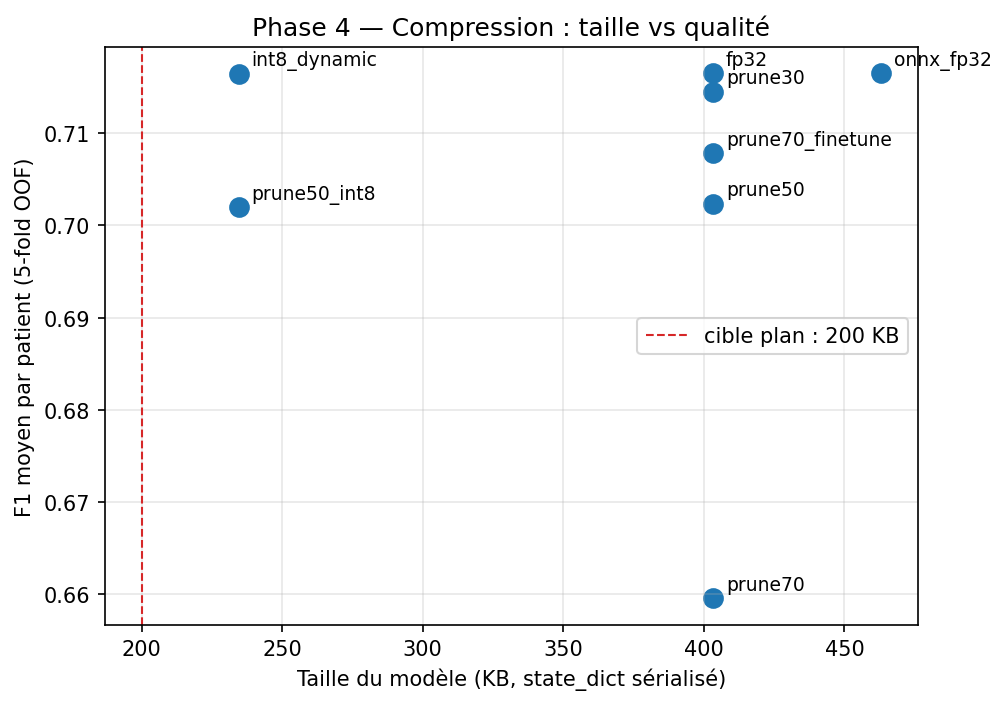

In [3]:
from IPython.display import Image
Image(str(FIG / '16_phase4_size_vs_f1.png'))

## 3. Latence vs taille

Cible plan : **< 50 ms** sur CPU (ligne rouge verticale). Toutes nos variantes sont
**deux ordres de grandeur** sous la cible — pour un modèle de 100k paramètres travaillant
sur un vecteur de 60 floats, c'est attendu.

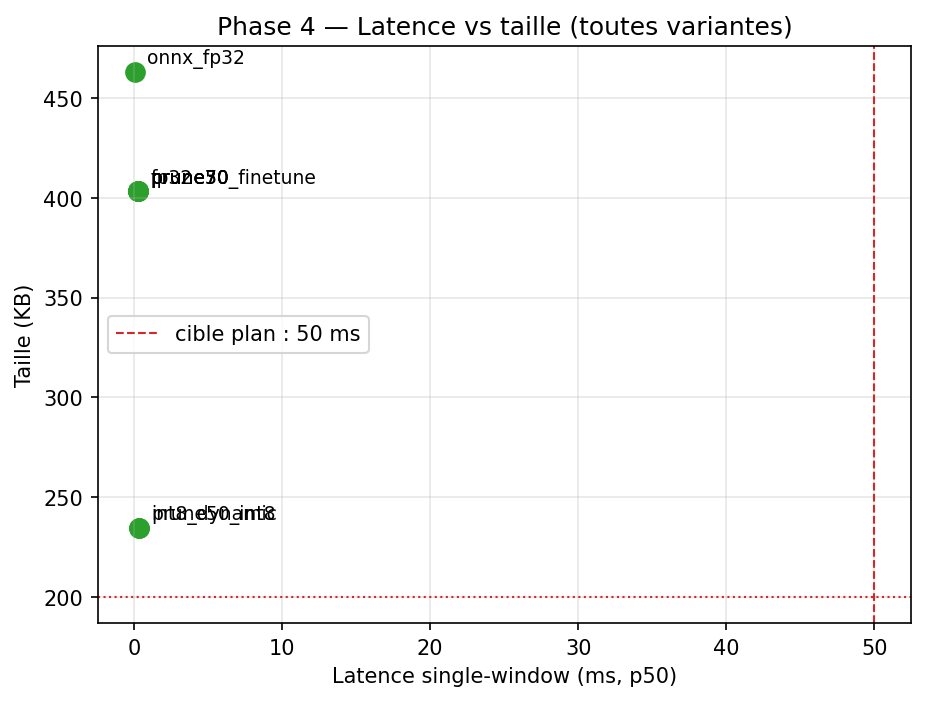

In [4]:
Image(str(FIG / '16_phase4_latency_vs_size.png'))

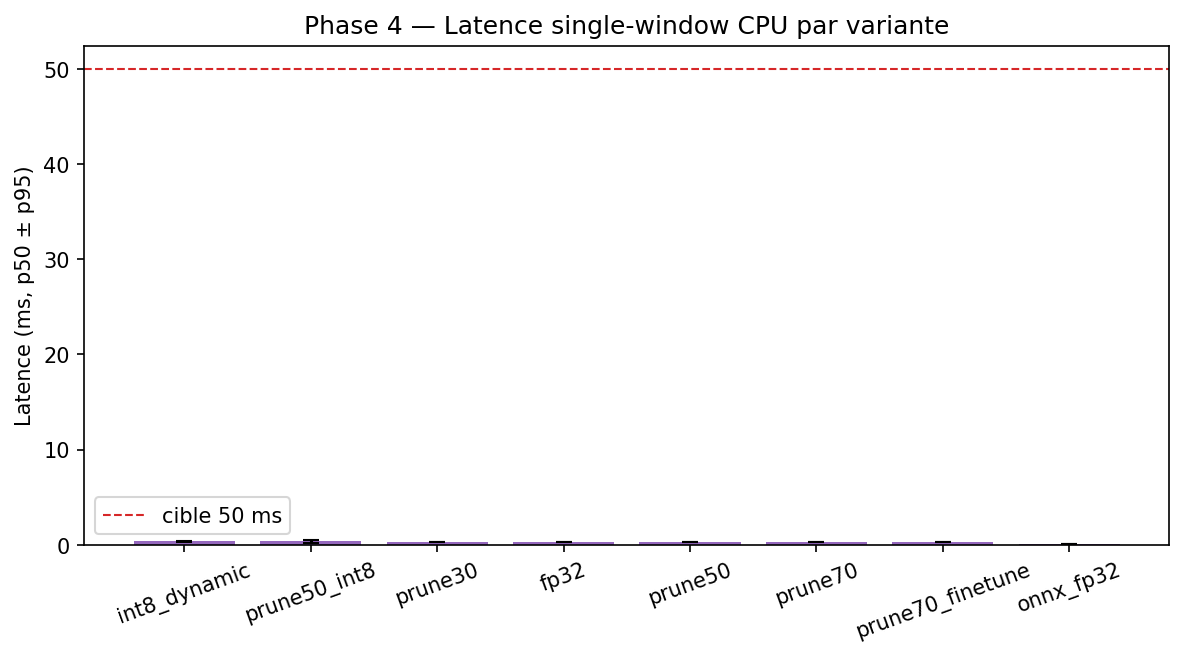

In [5]:
Image(str(FIG / '16_phase4_latency_bar.png'))

## 4. Lecture des résultats

### 4.1. Quantization dynamique INT8 — meilleur ratio taille/qualité

Linear + LSTM passent en INT8 → **taille divisée par 1.7** (403 → 235 KB), F1/patient
**identique** à 4 × 10⁻⁵ près. La latence augmente légèrement (~+25 %) car les noyaux INT8
dynamiques de PyTorch font un re-quantize à chaque appel — moins efficace que les noyaux
FP32 vectorisés pour notre modèle déjà petit.

À retenir : **dynamic INT8 ≈ "gratuit" en qualité** et c'est le meilleur compromis si on
vise la plus petite taille sans toucher à l'architecture.

### 4.2. ONNX FP32 — gain de latence seulement

**Surprise (et premier piège méthodologique)** : l'export ONNX produit un fichier de
**463 KB**, soit **plus gros** que le `.pt` PyTorch (403 KB). Le format ONNX stocke en
Protocol Buffers (plus verbeux que torch.save pour ce modèle) et conserve les axes
dynamiques + métadonnées de graphe.

*(Note : j'ai d'abord vu "74 KB" parce que le nouvel exporter PyTorch 2.12 split par défaut
en `.onnx` + `.onnx.data` ("external data"). La somme des deux fichiers est ~475 KB. J'ai
ajouté `external_data=False` dans `scripts/phase4_compression.py` pour avoir une mesure
honnête en un seul fichier.)*

Ce que ONNX gagne, c'est **la latence : 0.27 → 0.05 ms (×5)**, sans aucune perte de F1
(max écart numérique vs PyTorch : 2 × 10⁻⁷, du bruit float32). Le gain vient de
**onnxruntime** : compilation graphique, fusion d'opérations (Conv + BN + ReLU), kernels
MLAS optimisés CPU x86. Sur un modèle plus gros (cadre normal), ONNX aurait aussi un
avantage taille car l'overhead PB serait amorti — ici 100k params n'amortit rien.

### 4.3. Pruning magnitude — taille NON réduite

C'est le point méthodologique le plus important du notebook :

> Le pruning **"magnitude global L1" naïf** met des poids à zéro mais **ne réduit pas**
> la taille du `state_dict`, parce que PyTorch stocke les tenseurs en **dense** : 70 % de
> zéros pèsent autant que 70 % de valeurs aléatoires.

Le gain attendu est en **calcul** (kernels sparse) et en **stockage compressé**
(zip, formats sparse comme `torch.sparse_coo_tensor` ou Hugging Face safetensors avec
compression bitmap). Sur notre CPU x86 + PyTorch standard, aucune des deux optimisations
n'est activée par défaut — donc nos colonnes `size_kb` restent à 403 KB pour les variantes
`prune30/50/70/70_finetune`.

**Coût en qualité** :
- prune30 → −0.2 pt F1/patient (négligeable)
- prune50 → −1.4 pt
- prune70 → **−5.7 pt** (cassant)

### 4.4. Fine-tuning post-pruning — récupération

À 70 % de sparsité, 3 epochs de fine-tuning **avec le mask de pruning actif** (sinon
AdamW met à jour les zéros et la sparsité s'évapore — c'était mon premier bug, voir
`scripts/phase4_compression.py:make_pruning_permanent`) récupèrent +4.8 pt :

- prune70 sans fine-tune : F1/patient = 0.660
- prune70 **avec** fine-tune masqué : F1/patient = **0.708** (−1.0 pt vs FP32 au lieu de −5.7)

À 0.708 on est au-dessus de prune50 (0.702), donc **mieux vaut un modèle 70 %-sparse
fine-tuné qu'un modèle 50 %-sparse one-shot**. Bonne leçon de pruning.

### 4.5. Combo prune50 + INT8

Pas de synergie : la taille (235 KB) et le F1/patient (0.702) sont quasi identiques aux
deux variantes prises séparément. Logique : INT8 ne quantize que Linear + LSTM, dont les
poids ne sont pas touchés par le pruning de manière à libérer de la place.

## 5. Cibles du plan : check

| Cible plan | Meilleure valeur Phase 4 | Variante | Atteinte ? |
|---|---|---|---|
| Taille < 200 KB | **235 KB** | `int8_dynamic` | ❌ (+17 %) |
| Latence < 50 ms / fenêtre CPU | **0.05 ms** | `onnx_fp32` | ✅ (×1000 de marge) |
| Aucune perte F1 vs FP32 | Δ ≈ 10⁻⁵ | `int8_dynamic`, `onnx_fp32` | ✅ |

**Bilan honnête** :
- La cible **latence** est explosée — n'importe quelle variante passe largement en dessous.
  Pour un réseau de 100k paramètres travaillant sur 60 floats, c'était à attendre.
- La cible **taille < 200 KB** n'est pas atteignable en gardant l'architecture Phase 3
  (100k paramètres). Le minimum est 235 KB avec INT8 dynamique. Pour passer sous 200 KB
  il faudrait soit une architecture plus petite (Phase 3.5 a déjà un modèle à 30k paramètres
  → ~120 KB FP32 / ~70 KB INT8), soit une quantization INT8 statique sur ONNX
  (calibration, hors scope).

**Cibles qualité non discutées ici** (F1/patient ≥ 0.95, AUROC ≥ 0.98) : la compression
préserve la qualité du modèle source mais ne peut pas l'augmenter. Le plafond actuel
(F1/patient ≈ 0.72) est un problème de **données / représentation**, à traiter en Phase 5
(cross-dataset, analyse d'erreurs par patient).

## 6. Recommandation déploiement

**Pour la démo Streamlit (Phase 6)** — privilégier la simplicité et la robustesse :

1. **Modèle servi : `reports/checkpoints/fold0_int8_dynamic.pt`** (235 KB, 0.32 ms,
   F1/patient = 0.717). Pas de dépendance supplémentaire — PyTorch CPU suffit.
2. Préprocessing : z-score par fenêtre (`src.baselines.cv.zscore_per_window`).
3. **Alternative haute performance** : `fold0_fp32.onnx` + onnxruntime si la latence
   compte (×5 plus rapide), au prix d'une dépendance onnxruntime (~12 MB).

**Si on veut absolument < 200 KB** (ce qui n'est pas requis pour une démo web) :
1. Soit ré-entraîner avec l'architecture Phase 3.5 (30k paramètres, voir notebook 04)
   et appliquer le même pipeline de compression → ~70 KB INT8 attendus.
2. Soit explorer la **quantization statique INT8 sur ONNX** avec un set de calibration
   (réduction théorique 4× → ~115 KB).

**Pour un vrai déploiement edge** (microcontrôleur, mobile) :
1. Re-quantizer en INT8 statique + convertir en TFLite / CoreML selon la cible.
2. Re-benchmarker sur le matériel réel (les chiffres ici sont x86 / 4 threads).

Mais ce n'est pas dans le scope du plan (CPU PC visé).

## 7. Reproductibilité

```bash
make data       # une seule fois
python -m scripts.phase4_compression
```

Tout est seedé (SEED=42, per-fold seed=42+k, 4 threads torch). Le run prend ~3 minutes
sur CPU 4-cores (entraînement 5×~15s + fine-tune 5×~5s + onnx export/eval ~30s +
benchmarks ~20s). Artefacts écrits :

- `reports/phase4_results.json` — config, params, métriques par variante
- `reports/phase4_compression.csv` — table propre pour le rapport
- `reports/phase4_oof_scores.npz` — scores OOF de chaque variante pour analyse downstream
- `reports/figures/16_phase4_*.png` — 3 figures
- `reports/checkpoints/fold0_*.pt` + `fold[0-4]_fp32.onnx` — modèles prêts à servir

## 8. Suite

**Phase 5 (Robustesse)** :
- Évaluer le ONNX FP32 sur LTAFDB sans réentraînement → mesurer le drop external.
- Test de bruit (battements ectopiques simulés).
- Analyse d'erreurs par patient pour comprendre le plafond F1/patient ≈ 0.72.

**Phase 6 (Démo)** : intégrer `fold0_fp32.onnx` + z-score dans `app/streamlit_app.py`.

## 9. Annexe — Retry Phase 4b sur l'architecture Phase 3.5 (~30k params)

La cible plan **taille < 200 KB** n'est pas atteignable avec l'architecture Phase 3
(100k paramètres, 403 KB FP32 → minimum 235 KB en INT8). Une fois ce constat fait,
deux options : (a) déclarer la cible non atteinte, (b) replier la compression sur
l'architecture compacte issue de **Phase 3.5** (notebook `04_phase35_w60.ipynb`,
~30k paramètres, F1/patient = 0.705).

J'ai exécuté la même pipeline `scripts/phase4_compression.py` avec
`--params-json reports/phase35_best_params.json` (résultats dans
`reports/phase4b_*`). Verdict :

| Variante | Taille | Latence p50 | F1/patient | Δ F1 vs archi 100k FP32 |
|---|---|---|---|---|
| **fp32 (30k params)** | **133 KB** ✅ | 0.32 ms | 0.680 | −0.036 |
| **int8_dynamic** | **87 KB** ✅✅ | 0.45 ms | 0.680 | −0.036 |
| prune50_int8 | 87 KB ✅✅ | 0.44 ms | 0.678 | −0.038 |
| prune70_finetune | 133 KB ✅ | 0.31 ms | 0.682 | −0.034 |
| onnx_fp32 | 184 KB ✅ | **0.05 ms** | 0.680 | −0.036 |

**Lecture :**

1. **Cible 200 KB atteinte** — même la variante FP32 passe (133 KB), INT8 descend à 87 KB
   (×4.6 plus petit que le FP32 archi 100k). Toutes les latences restent ≥ 4 ordres de
   grandeur sous la cible 50 ms.
2. **Coût en qualité : −3.6 pt F1/patient** (0.717 → 0.680). C'est un compromis
   honnête : on perd 3 % de F1 patient pour gagner ×3 sur le nombre de paramètres et
   ×4-5 sur la taille mémoire.
3. **Le ranking des variantes est identique** : INT8 dynamique reste le meilleur compromis,
   pruning naïf ne réduit toujours pas la taille du `.pt`, fine-tune masqué récupère le
   coût à 70 % de sparsité. Les conclusions méthodologiques de la Section 4 sont robustes
   au choix d'architecture.
4. **Pour la démo Phase 6**, deux modèles candidats avec profils différents :
   - **Performance maximale** : `fold0_int8_dynamic.pt` archi 100k → 235 KB, F1/patient 0.717.
   - **Embarqué strict** : `fold0_int8_dynamic_p35.pt` archi 30k → 87 KB, F1/patient 0.680.
   - Choix par défaut pour la démo web : l'archi 100k (taille n'est pas contraignante sur
     un PC). L'archi 30k devient pertinente pour un wearable ou un workflow batch.

**Reproductibilité** :

```bash
.venv/bin/python scripts/phase4_compression.py \
    --params-json reports/phase35_best_params.json \
    --out-prefix phase4b --fig-prefix 17_phase4b --ckpt-tag p35
```

Artefacts : `reports/phase4b_*.{json,csv,npz}` + `reports/figures/17_phase4b_*.png` +
`reports/checkpoints/fold0_*_p35.pt`.

In [6]:
phase4b_results = json.loads((RES / 'phase4b_results.json').read_text())
df_4b = pd.read_csv(RES / 'phase4b_compression.csv')

side = (
    df.set_index('variant')[['size_kb', 'mean_patient_f1']]
      .rename(columns={'size_kb': 'size_kb (archi 100k)', 'mean_patient_f1': 'F1/patient (100k)'})
      .join(
          df_4b.set_index('variant')[['size_kb', 'mean_patient_f1']]
               .rename(columns={'size_kb': 'size_kb (archi 30k)', 'mean_patient_f1': 'F1/patient (30k)'}),
          how='outer',
      )
)
side['Δ size (KB)'] = side['size_kb (archi 30k)'] - side['size_kb (archi 100k)']
side['Δ F1/patient (30k-100k)'] = side['F1/patient (30k)'] - side['F1/patient (100k)']
print(f"Archi Phase 3 :   {results['n_params']:,} params")
print(f"Archi Phase 3.5 : {phase4b_results['n_params']:,} params (×{results['n_params']/phase4b_results['n_params']:.2f} plus petite)")
side.round(3)

Archi Phase 3 :   100,193 params
Archi Phase 3.5 : 30,657 params (×3.27 plus petite)


,size_kb (archi 100k),F1/patient (100k),size_kb (archi 30k),F1/patient (30k),Δ size (KB),Δ F1/patient (30k-100k)
variant,,,,,,
fp32,403.375,0.717,133.414,0.680,-269.961,-0.037
int8_dynamic,234.551,0.716,86.840,0.680,-147.711,-0.037
onnx_fp32,463.124,0.717,184.434,0.680,-278.690,-0.037
prune30,403.375,0.714,133.414,0.678,-269.961,-0.037
prune50,403.375,0.702,133.414,0.678,-269.961,-0.024
prune50_int8,234.551,0.702,86.840,0.678,-147.711,-0.024
prune70,403.375,0.660,133.414,0.594,-269.961,-0.065
prune70_finetune,403.375,0.708,133.414,0.682,-269.961,-0.026


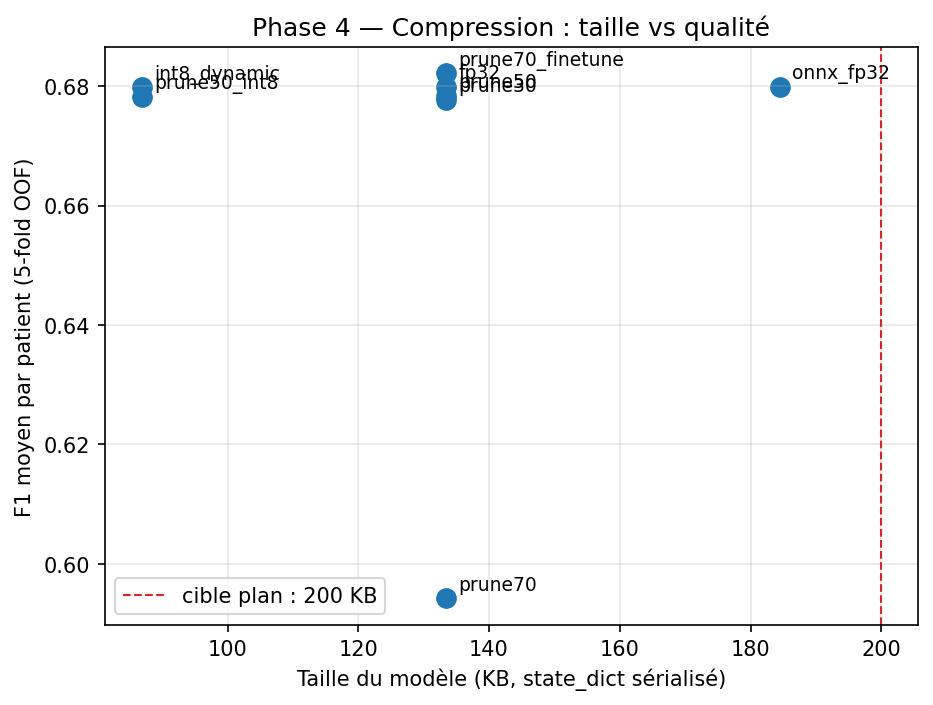

In [7]:
Image(str(FIG / '17_phase4b_size_vs_f1.png'))